In [2]:
import pandas as pd
from Hydrograph.hydrograph import sepBaseflow
import matplotlib.pyplot as plt

In [3]:
#Lendo o arquivo com dados

df = pd.read_csv('corumbatai.csv')

df.head()

,Data,Qobs
0,01/01/1985,19.513
1,01/02/1985,15.230
2,01/03/1985,12.898
3,01/04/1985,11.395
4,01/05/1985,11.767


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12783 entries, 0 to 12782
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Data    12783 non-null  object 
 1   Qobs    12783 non-null  float64
dtypes: float64(1), object(1)
memory usage: 199.9+ KB


In [5]:
df['Data'] = pd.to_datetime(df['Data'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12783 entries, 0 to 12782
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Data    12783 non-null  datetime64[ns]
 1   Qobs    12783 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 199.9 KB


In [7]:
df.rename(columns={
    'Data': 'Date',
    'Qobs': 'Total runoff [m^3 s^-1]'
}, inplace=True)

In [8]:
for num, col in enumerate(df.columns):
    print(f'Coluna {num}: {col}')

Coluna 0: Date
Coluna 1: Total runoff [m^3 s^-1]


In [9]:
df

,Date,Total runoff [m^3 s^-1]
0,1985-01-01,19.513
1,1985-01-02,15.230
2,1985-01-03,12.898
3,1985-01-04,11.395
4,1985-01-05,11.767
...,...,...
12778,2019-12-27,12.483
12779,2019-12-28,11.785
12780,2019-12-29,11.103
12781,2019-12-30,10.436


In [10]:
#Definindo a coluna de datas ("Date") como um Datetime index

df.set_index('Date', inplace=True)

In [11]:
#Conferindo

df

,Total runoff [m^3 s^-1]
Date,
1985-01-01,19.513
1985-01-02,15.230
1985-01-03,12.898
1985-01-04,11.395
1985-01-05,11.767
...,...
2019-12-27,12.483
2019-12-28,11.785
2019-12-29,11.103


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12783 entries, 1985-01-01 to 2019-12-31
Data columns (total 1 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Total runoff [m^3 s^-1]  12783 non-null  float64
dtypes: float64(1)
memory usage: 199.7 KB


In [13]:
#Obtendo apenas uma parte da amostra para testes

df = df.loc['1985-01-01': '1985-12-31']

In [14]:
ano_min = df.index.min().year
ano_max = df.index.max().year
periodo = (ano_max - ano_min) + 1
print(f'Comprimento da série: {periodo} ano(s).')

Comprimento da série: 1 ano(s).


In [15]:
#Visualizando o df

df

,Total runoff [m^3 s^-1]
Date,
1985-01-01,19.513
1985-01-02,15.230
1985-01-03,12.898
1985-01-04,11.395
1985-01-05,11.767
...,...
1985-12-27,20.780
1985-12-28,20.144
1985-12-29,39.215


In [16]:
"""
Definindo os parâmetros "Area" e "k" da função sepBaseflow da biblioteca Hydrograph-py.

Area: área da bacia hidrográfica em km^2;
k: define a inclinação da curva do escoamento de base durante o evento de chuva.
"""

Area = 1718.47
k = 0.0000135987

In [17]:
df2 = sepBaseflow(df, 60, Area, k, dt_max=24, tp_min=6)

Processing using a 60-minute interval...
1985-01-01 00:00:00
1985-01-01 01:00:00
1985-01-01 02:00:00
1985-01-01 03:00:00
1985-01-01 04:00:00
1985-01-01 05:00:00
1985-01-01 06:00:00
1985-01-01 07:00:00
1985-01-01 08:00:00
1985-01-01 09:00:00
1985-01-01 10:00:00
1985-01-01 11:00:00
1985-01-01 12:00:00
1985-01-01 13:00:00
1985-01-01 14:00:00
1985-01-01 15:00:00
1985-01-01 16:00:00
1985-01-01 17:00:00
1985-01-01 18:00:00
1985-01-01 19:00:00
1985-01-01 20:00:00
1985-01-01 21:00:00
1985-01-01 22:00:00
1985-01-01 23:00:00
1985-01-02 00:00:00
1985-01-02 01:00:00
1985-01-02 02:00:00
1985-01-02 03:00:00
1985-01-02 04:00:00
1985-01-02 05:00:00
1985-01-02 06:00:00
1985-01-02 07:00:00
1985-01-02 08:00:00
1985-01-02 09:00:00
1985-01-02 10:00:00
1985-01-02 11:00:00
1985-01-02 12:00:00
1985-01-02 13:00:00
1985-01-02 14:00:00
1985-01-02 15:00:00
1985-01-02 16:00:00
1985-01-02 17:00:00
1985-01-02 18:00:00
1985-01-02 19:00:00
1985-01-02 20:00:00
1985-01-02 21:00:00
1985-01-02 22:00:00
1985-01-02 23:00:00

c:\Users\wande\AppData\Local\Programs\Python\Python314\Lib\site-packages\Hydrograph\hydrograph.py:57: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dr = pd.date_range(minDate, maxDate, freq='60T')  #-60-minute interval


1985-02-01 00:00:00
1985-02-01 01:00:00
1985-02-01 02:00:00
1985-02-01 03:00:00
1985-02-01 04:00:00
1985-02-01 05:00:00
1985-02-01 06:00:00
1985-02-01 07:00:00
1985-02-01 08:00:00
1985-02-01 09:00:00
1985-02-01 10:00:00
1985-02-01 11:00:00
1985-02-01 12:00:00
1985-02-01 13:00:00
1985-02-01 14:00:00
1985-02-01 15:00:00
1985-02-01 16:00:00
1985-02-01 17:00:00
1985-02-01 18:00:00
1985-02-01 19:00:00
1985-02-01 20:00:00
1985-02-01 21:00:00
1985-02-01 22:00:00
1985-02-01 23:00:00
1985-02-02 00:00:00
1985-02-02 01:00:00
1985-02-02 02:00:00
1985-02-02 03:00:00
1985-02-02 04:00:00
1985-02-02 05:00:00
1985-02-02 06:00:00
1985-02-02 07:00:00
1985-02-02 08:00:00
1985-02-02 09:00:00
1985-02-02 10:00:00
1985-02-02 11:00:00
1985-02-02 12:00:00
1985-02-02 13:00:00
1985-02-02 14:00:00
1985-02-02 15:00:00
1985-02-02 16:00:00
1985-02-02 17:00:00
1985-02-02 18:00:00
1985-02-02 19:00:00
1985-02-02 20:00:00
1985-02-02 21:00:00
1985-02-02 22:00:00
1985-02-02 23:00:00
1985-02-03 00:00:00
1985-02-03 01:00:00


c:\Users\wande\AppData\Local\Programs\Python\Python314\Lib\site-packages\Hydrograph\hydrograph.py:152: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NaT' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_final.loc[df_final['Peak nr.'] ==i, 'Date max. flow'] = mdate


In [18]:
#Cópia do dataframe para análises posteriores

df3 = df2.copy(deep=True)

In [19]:
#Obtendo a vazão calc
df3['Vazao_calc_cms'] = df3.apply(lambda x: (x['Baseflow [m^3 s^-1]'] + x['Peakflow [m^3 s^-1]']), axis=1)

#Selecionando as colunas desejadas
colunas_selecionadas = ['Vazao_calc_cms', 'Baseflow [m^3 s^-1]', 'Peakflow [m^3 s^-1]']
df3 = df3.loc[:, colunas_selecionadas]

#Renomeando
df3.rename(columns={
    'Baseflow [m^3 s^-1]': 'Esc_base_cms',
    'Peakflow [m^3 s^-1]': 'Esc_superficial_cms'
}, inplace=True)

df3

,Vazao_calc_cms,Esc_base_cms,Esc_superficial_cms
Date,,,
1985-01-01 00:00:00,19.513000,19.513000,0.000000
1985-01-01 01:00:00,19.334542,19.334542,0.000000
1985-01-01 02:00:00,19.156083,19.156083,0.000000
1985-01-01 03:00:00,18.977625,18.977625,0.000000
1985-01-01 04:00:00,18.799167,18.799167,0.000000
...,...,...,...
1985-12-30 20:00:00,16.408500,12.875219,3.533281
1985-12-30 21:00:00,15.722625,12.898588,2.824037
1985-12-30 22:00:00,15.036750,12.921957,2.114793


In [20]:
#Reamostragem dos dados de escala horária para diária

df3 = df3.resample('D').agg({
    'Vazao_calc_cms': 'mean',
    'Esc_base_cms': 'mean',
    'Esc_superficial_cms': 'mean'})

df3

,Vazao_calc_cms,Esc_base_cms,Esc_superficial_cms
Date,,,
1985-01-01,17.460729,17.460729,0.000000
1985-01-02,14.112583,14.112583,0.000000
1985-01-03,12.177812,12.177812,0.000000
1985-01-04,11.573250,11.573250,0.000000
1985-01-05,12.308937,12.035743,0.273194
...,...,...,...
1985-12-27,20.475250,10.994018,9.481232
1985-12-28,29.282188,11.554873,17.727315
1985-12-29,34.859854,12.115728,22.744126


## Visualizando

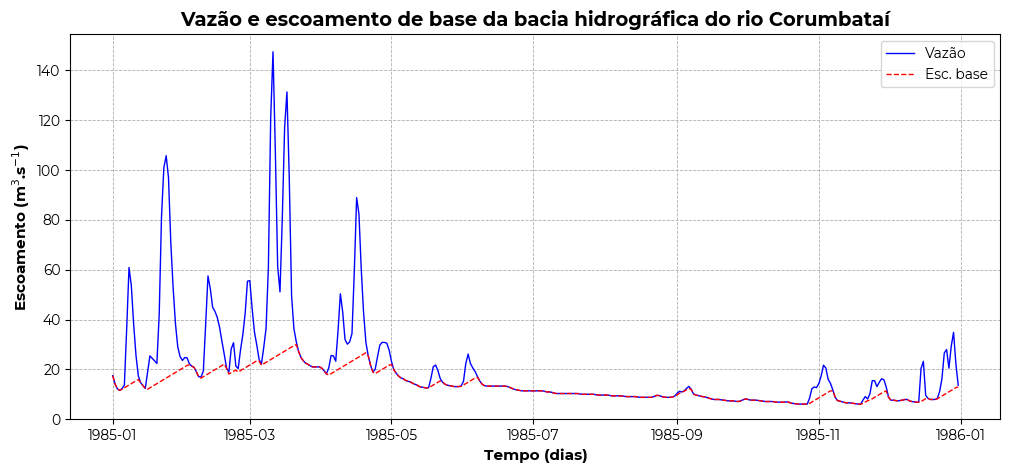

In [24]:
#Configurando a figura
plt.figure(figsize=(12, 5))

#Plotando vazão e escoamento de base
plt.plot(df3.index, df3['Vazao_calc_cms'], color='b', lw=1.0, ls='-', label='Vazão')
plt.plot(df3.index, df3['Esc_base_cms'], color='r', lw=1.0, ls='--', label='Esc. base')

#Demais elementos do gráfico
plt.title('Vazão e escoamento de base da bacia hidrográfica do rio Corumbataí', fontsize=14, color='k', weight='bold')
plt.ylabel('Escoamento (m$^{3}$.s$^{-1}$)', fontsize=11, color='k', weight='bold')
plt.xlabel('Tempo (dias)', fontsize=11, color='k', weight='bold')
plt.ylim(0, None)
plt.legend()
plt.grid(True, lw=0.6, ls='--')

#plt.xlim(dt.datetime(1985, 1, 1), dt.datetime(1985, 2, 25))    # Para filtrar um determinado período no gráfico

#Salvando a figura
# plt.savefig('baseflow_plot.png', facecolor='w', bbox_inches='tight', dpi=300)

plt.show()

In [25]:
import seaborn as sns
import datetime as dt
from matplotlib import font_manager

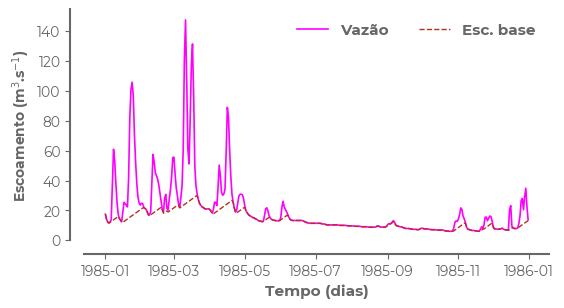

In [26]:
# Registra o arquivo da fonte no Matplotlib
font_path = 'C:/Users/wande/Downloads/Montserrat/static/Montserrat-Regular.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)

# Define essa fonte como a padrão no rcParams pelo nome dela
plt.rcParams['font.family'] = prop.get_name()

#Configurando a figura
fig, ax = plt.subplots(figsize=(6, 3))

#Plotando vazão e escoamento de base
ax.plot(df3.index, df3['Vazao_calc_cms'], color='magenta', lw=1.2, ls='-', label='Vazão')   # '#100552'
ax.plot(df3.index, df3['Esc_base_cms'], color="#B3321B", lw=1.0, ls='--', label='Esc. base')

#Cor demais itens
cor_itens = "#686767"

#Demais elementos do gráfico
plt.ylabel('Escoamento (m$^{3}$.s$^{-1}$)', fontsize=10, color=cor_itens, fontweight='bold')
plt.xlabel('Tempo (dias)', fontsize=11, color=cor_itens, weight='bold')
plt.ylim(0, None)
ax.legend(loc='upper right', alignment='left', ncols=2, frameon=False, labelcolor=cor_itens, prop={
    'size': 11,
    'weight': 'bold',
    'style': 'normal'})


# Alterando a cor das spines
for spine in ax.spines.values():
    spine.set_color(cor_itens)

# Remove o topo e o lado direito por padrão
sns.despine()

ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

# Altera a cor dos ticks (colors) e dos números (labelcolor)
ax.tick_params(axis='both', colors=cor_itens, labelcolor=cor_itens)


#Salvando a figura
plt.savefig('imgs/baseflow_plot2.png', facecolor='w', bbox_inches='tight', dpi=300)

plt.show()